# Week 8 - Multivariate Analysis

## Please run the cells of the notebook as you get to them while reading

In [1]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import seaborn as sns
from sklearn import decomposition
from sklearn import linear_model
from sklearn import metrics

# 1. Lesson: Multivariate graphs

In this lesson, we'll consider some multivariate plots: heatmaps and bubble plots.  We'll also consider principal component analysis and multiple regression.

### Heatmaps

In this plot, we use a heatmap to count the total traffic tickets given to citizens.  A heatmap requires the x and y axes to be categorical, while the color involves a third, numerical variable.  In this example, each row of the DataFrame represents a traffic ticket given to one person in a particular city and year.  The data are given as three columns (city, year, and ticket), so we must use a pivot_table to transform it into a two-dimensional grid.  The cmap is set to "Blues" in the first example, meaning that the heatmap uses only blue as its color.  However, we could also use a multicolor map like "viridis" in the second example.  I personally think "Blues" is easier to read - what do you think?  Here is a reference guide to the color maps:

https://matplotlib.org/stable/gallery/color/colormap_reference.html

In [2]:
np.random.seed(0)
num_samples = 100
city_series = np.random.choice(["New York", "Boston", "Atlanta", "Washington, D. C."], size = num_samples)
year_series = np.random.choice([2018, 2019, 2020], size = num_samples)
ticket_series = np.random.randint(50, 150, size = num_samples) # Traffic tickets can be from $50 to $150
df = pd.DataFrame({"city": city_series, "year": year_series, "ticket": ticket_series})
pivot = df.pivot_table(index = ["city"], columns = ["year"], values = "ticket", aggfunc = "sum")

In [3]:
df.iloc[0:5] # first five rows of a long DataFrame

,city,year,ticket
0,New York,2019,79
1,"Washington, D. C.",2020,71
2,Boston,2018,75
3,New York,2018,130
4,"Washington, D. C.",2020,110


In [4]:
pivot # 2 by 2 grid showing total ticket amounts

year,2018,2019,2020
city,,,
Atlanta,742,440,538
Boston,775,628,922
New York,1122,841,596
"Washington, D. C.",1258,451,1385


Text(0.5, 1.0, 'Total traffic tickets by city and year')

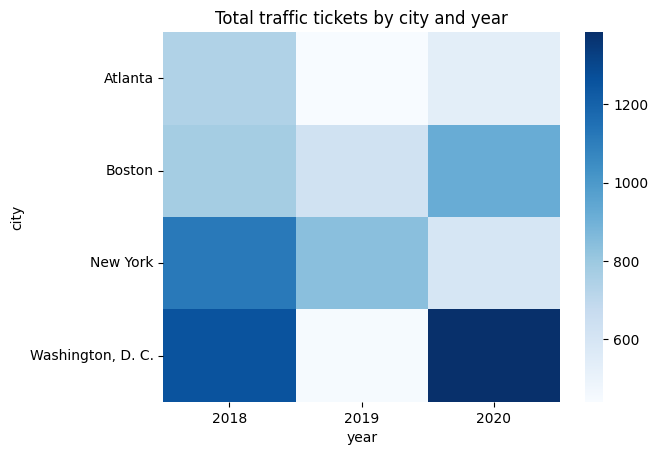

In [5]:
ax = sns.heatmap(pivot, cmap = "Blues")
ax.set_title("Total traffic tickets by city and year")

Text(0.5, 1.0, 'Average traffic ticket value by city and year')

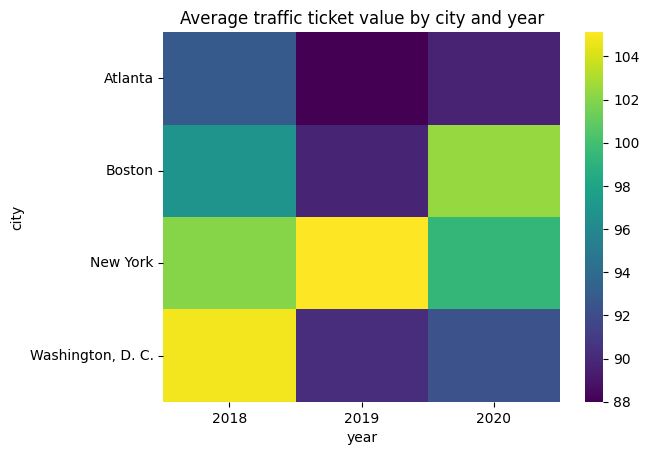

In [6]:
pivot2 = df.pivot_table(index = ["city"], columns = ["year"], values = "ticket", aggfunc = "mean") # note mean, not sum this time
ax2 = sns.heatmap(pivot2, cmap = "viridis") # do you think this is a better or worse scale than Blues?
ax2.set_title("Average traffic ticket value by city and year")

**Response:**

I can see why “Blues” might be considered easier to read—its simplicity makes it very accessible and doesn’t overwhelm the viewer. That said, I think the choice of colormap really depends on the context and the story you’re trying to tell with the data.

For example, if the goal is to emphasize clear differences in magnitude, especially over a wide range, I tend to prefer something like **"viridis"**. It has a broader color gradient and is perceptually uniform, which helps highlight subtle variations more effectively.

But for cleaner presentations or when simplicity is the priority, especially in cases where the audience might not be as data-savvy, “Blues” definitely has its place. So I’d say both have merit—it just depends on the use case and audience.

### Bubble plots

A bubble plot is just a scatter plot, but with the dot size representing a third variable.  Here, each data point shows a tree (I mean the kind of tree that is a plant and grows in the ground, not a decision tree), with its height, width of branches, and root depth.  The bubble size in the bubble plot represents the root depth, while the other variables are shown on the x and y axes.  From this plot, we can see that the root depth is strongly correlated with both the width of branches and the tree height.

Text(0, 0.5, 'width of branches')

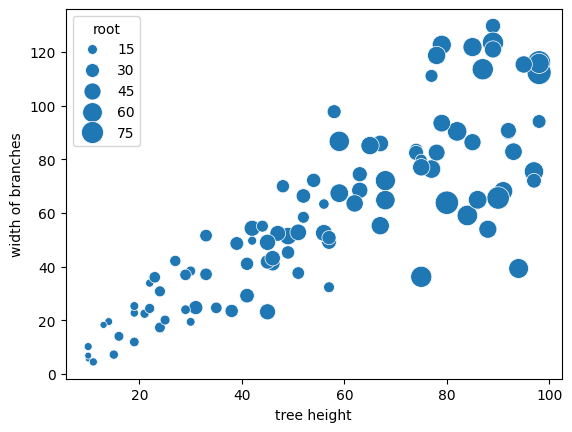

In [8]:
np.random.seed(0)
num_samples = 100
height_series = np.random.randint(10, 100, size = num_samples) # tree height
width_series = height_series * np.maximum(np.random.normal(scale = 0.3, loc = 1, size = num_samples), 0.25) # strongly related to height
root_series = height_series * np.maximum(np.random.normal(scale = 0.2, loc = 0.7, size = num_samples), 0.3) # strongly related to height
df2 = pd.DataFrame({'height': height_series, 'width': width_series, 'root': root_series})
minroot = root_series.min()
maxroot = root_series.max()
maxbubble = 300
ax = sns.scatterplot(data = df2, x = "height", y = "width", size = "root", sizes = (minroot / maxroot * maxbubble, maxbubble))
ax.set_xlabel("tree height")
ax.set_ylabel("width of branches")

### Principal Component Analysis

Principal Component Analysis can be thought of as a way to use one (or a few) linear combinations of the coordinates in order to explain all of the coordinates.  It is most useful when there are strong correlations between some or all of the coordinates.  Principal Component Analysis can show us which linear combinations are most (and least) useful for explaining the data.

With the trees data, the three values (height, width, and root) are highly correlated.  For this reason, Principal Component Analysis shows that most of the variance can be explained by a single value which is a linear combination of height, width, and root.  What this means is that if the first components_ vector in the code below (the "first principal component") is \[a, b, c\], for some specific numbers a, b, and c, then the value v = a * (height - mu_h) + b * (width - mu_w) + c * (root - mu_r), where the mu's are the means, is highly informative about the values of height, width, and root.  In this case, because height, width, and root are so highly correlated, we can almost assume that all of the data is located along an axis defined by the vector \[a, b, c\].  The point v * \[a, b, c\] + (mean vector) = (a * (height - mu_h) + b * (width - mu_w) + c * (root - mu_r)) * \[a, b, c\] + (mean vector) is therefore approximately equal to the data point (height, width, root) in question.  The mean vector is \[mu_h, mu_w, mu_r\].  Importantly, there is still variance unexplained by this one value - just knowing v * \[a, b, c\] does not tell you the height, width, and root with 100% accuracy.  If the second principal component is \[d, e, f\], then we could approximate the tree vector even more accurately as: (height, width, root) = (a * (height - mu_h) + b * (width - mu_w) + c * (root - mu_r)) * \[a, b, c\] + (d * (height - mu_h) + e * (width - mu_w) + f * (root - mu_r)) * \[d, e, f\] + (mean vector).

The printing of "components_", below, shows the first principal component \[a, b, c\].  If you draw a vector in the direction shown, you will be heading in the direction where the values height, width, and root change most rapidly.  A later computation shows all three principal component vectors.

**Optional exercise for the reader:** show that if all three principal components are included, then equality is exact.  This is going to be true simply because the principal components are orthonormal: the projections onto a complete set of orthonormal vectors always add up to the original vector.

(height, width, root) = (a * (height - mu_h) + b * (width - mu_w) + c * (root - mu_r)) * \[a, b, c\] + (d * (height - mu_h) + e * (width - mu_w) + f * (root - mu_r)) * \[d, e, f\] + (g * (height - mu_h) + h * (width - mu_w) + i * (root - mu_r)) * \[g, h, i\] + \[mu_h, mu_w, mu_r\].

For this proof, we must use the fact that the principal component vectors are orthonormal.  That is, any pair of them are orthogonal, even with a transpose (ad + be + cf = 0, ag + bh + ci = 0, dg + eh + fi = 0, ab + de + gh = 0, ac + df + gi = 0, bc + ef + hi = 0) and any one of them is a unit vector, even with a transpose (a^2 + b^c + c^2 = 1, d^2 + e^2 + f^2 = 1, g^2 + h^2 + i^2 = 1, a^2 + d^2 + g^2 = 1, b^2 + e^2 + h^2 = 1, c^2 + f^2 + i^2 = 1).  If you write out the equation above as a single vector, then apply the orthonormality rules, you should be able to prove equality.

In [9]:
pca = decomposition.PCA(n_components = 1)
pca.fit(df2)
print(f"The first principal component explains {pca.explained_variance_ratio_[0]} of the variance")
print(f"The components_ vector is [a, b, c] = {pca.components_}")
mu_h, mu_w, mu_r = df2.mean().values
print(f"(height, width, root) is approximately equal to ({pca.components_[0][0]:.2} * (height - {mu_h:.2}) + {pca.components_[0][1]:.2} * (width - {mu_w:.2}) + {pca.components_[0][2]:.2} * (root - {mu_r:.2})) * ({pca.components_[0][0]:.2}, {pca.components_[0][1]:.2}, {pca.components_[0][2]:.2}) + ({mu_h:.2}, {mu_w:.2}, {mu_r:.2})")
print("Examples: (estimating the the vector equals its projection onto the first principal component)")
df_example = df2.copy()
df_example["v"] = pca.components_[0][0] * (df2["height"] - mu_h) + pca.components_[0][1] * (df2["width"] - mu_w) + pca.components_[0][2] * (df2["root"] - mu_r)
df_example["height_est"] = df_example["v"] * pca.components_[0][0] + mu_h
df_example["width_est"] = df_example["v"] * pca.components_[0][1] + mu_w
df_example["root_est"] = df_example["v"] * pca.components_[0][2] + mu_r
print(df_example.iloc[0:5])
print("Means:")
print(f"mu_h = {mu_h:.3}", f"mu_w = {mu_w:.3}", f"mu_r = {mu_r:.3}")

The first principal component explains 0.8686108480944689 of the variance
The components_ vector is [a, b, c] = [[0.59031629 0.71908728 0.36666083]]
(height, width, root) is approximately equal to (0.59 * (height - 5.6e+01) + 0.72 * (width - 5.9e+01) + 0.37 * (root - 3.6e+01)) * (0.59, 0.72, 0.37) + (5.6e+01, 5.9e+01, 3.6e+01)
Examples: (estimating the the vector equals its projection onto the first principal component)
   height       width       root          v  height_est  width_est   root_est
0      54   72.139334  31.517932   6.287751   60.001762  63.563941  38.673095
1      57   49.169527  33.768693  -7.633330   51.783921  53.553468  33.568780
2      74   83.443733  28.770850  25.215680   71.175227  77.174773  45.613225
3      77   76.353866  53.061241  30.794730   74.468631  81.186597  47.658844
4      77  111.095365  26.006307  45.856916   83.360084  92.017624  53.181557
Means:
mu_h = 56.3 mu_w = 59.0 mu_r = 36.4


If we were to choose a second or third component to preserve, that values below show that each would explain a small, additional amount of the variance.  This means that with this particular dataset, we should likely do PCA using only one component and not two.  If the components' explained variances were closer in magnitude to each other, we might have to include two or even all three values to explain the data.

In [10]:
pca3 = decomposition.PCA(n_components = 3)
pca3.fit(df2)
print(pca3.explained_variance_ratio_)
print(pca3.components_)

[0.86861085 0.09414617 0.03724298]
[[ 0.59031629  0.71908728  0.36666083]
 [ 0.32633701 -0.62809127  0.70640322]
 [ 0.73826204 -0.29734633 -0.6054373 ]]


The principal component vectors shown are orthogonal to each other (their dot product is basically zero).  Here, we check that using the first two vectors.

In [11]:
print(np.array(pca3.components_[0]).dot(np.array(pca3.components_[1])))

-1.6653345369377348e-16


We can use the projection onto the first principal component as if it were a new feature.  For instance, we could plot a histogram of the data against the magnitude of the projection onto the first principal component.  In fact, for some purposes, this magnitude (which we have called v) might make a better feature for data analysis than either height, width, or root.  We must subtract off the mean before the dot product; the understanding is that this represents the component of the data relative to the mean.

<Axes: >

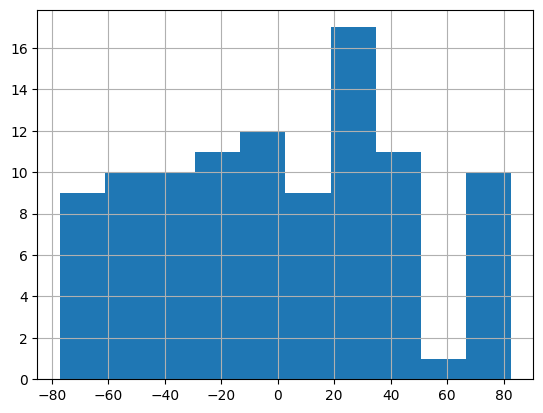

In [12]:
((df2 - df2.mean()).dot(np.array(pca.components_[0]))).hist()

In [13]:
# Showing that this is the same as the value we've called "v"
(df_example["v"] - (df2 - df2.mean()).dot(np.array(pca.components_[0]))).max()

np.float64(0.0)

### Linear Regression

Now let's run a linear regression model to predict the root from the height and width, as well as predicting the third principal component from the first and second.  Which is easier to predict?

### Predicting the root from the height and width

In [14]:
linreg = linear_model.LinearRegression()
linreg.fit(df2[['height', 'width']], df2['root'])
preds = linreg.predict(df2[['height', 'width']])
metrics.mean_squared_error(preds, df2['root']) # Mean squared error as a metric

138.22487356329611

In [15]:
np.corrcoef(preds, df2['root']) # Correlation coefficient as a metric

array([[1.        , 0.79468295],
       [0.79468295, 1.        ]])

### Predicting the third principal component from the first and second

In [16]:
first_principal_component_score = (df2 - df2.mean()).dot(np.array(pca3.components_[0]))
second_principal_component_score = (df2 - df2.mean()).dot(np.array(pca3.components_[1]))
third_principal_component_score = (df2 - df2.mean()).dot(np.array(pca3.components_[2]))

In [17]:
linreg_first = linear_model.LinearRegression()
pc_X = np.array([first_principal_component_score, second_principal_component_score]).T
linreg_first.fit(pc_X, third_principal_component_score)
preds = linreg_first.predict(pc_X)
metrics.mean_squared_error(preds, third_principal_component_score) # The mean squared error is a bit smaller here.

78.74928905273173

In [18]:
np.corrcoef(preds, third_principal_component_score) # More importantly, the correlation is basically zero

array([[1.00000000e+00, 1.55375616e-14],
       [1.55375616e-14, 1.00000000e+00]])

Here, we see that the projections of the first two principal components have no ability to predict the projection of the third, when measured by correlation.  This is a special property of principal components.  It is intended to ensure that the each component gives new information not present in the previous components.

The mean_squared_error is misleading - it makes it look like the error is less for the second computation than the first; but the correlation coefficient is giving more useful information here.  We cannot compare the mean squared error for two totally different computations, because mean squared error is highly dependent on the magnitudes of the values in question!

# 2. Weekly graph question

The tree data above can be graphed via either a pairplot or a bubble plot.  What are the advantages and disadvantages of each?

Text(0, 0.5, 'width of branches')

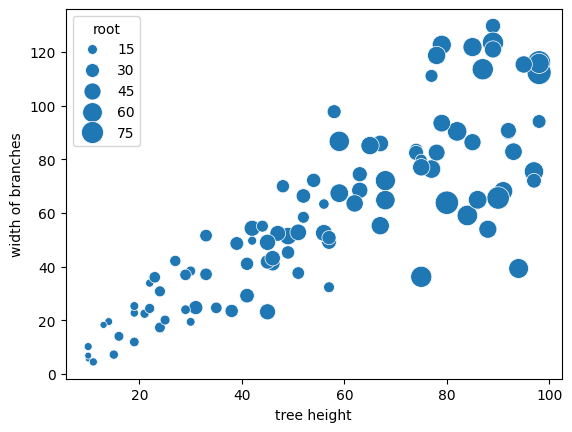

In [17]:
ax = sns.scatterplot(data = df2, x = "height", y = "width", size = "root", sizes = (minroot / maxroot * maxbubble, maxbubble))
ax.set_xlabel("tree height")
ax.set_ylabel("width of branches")

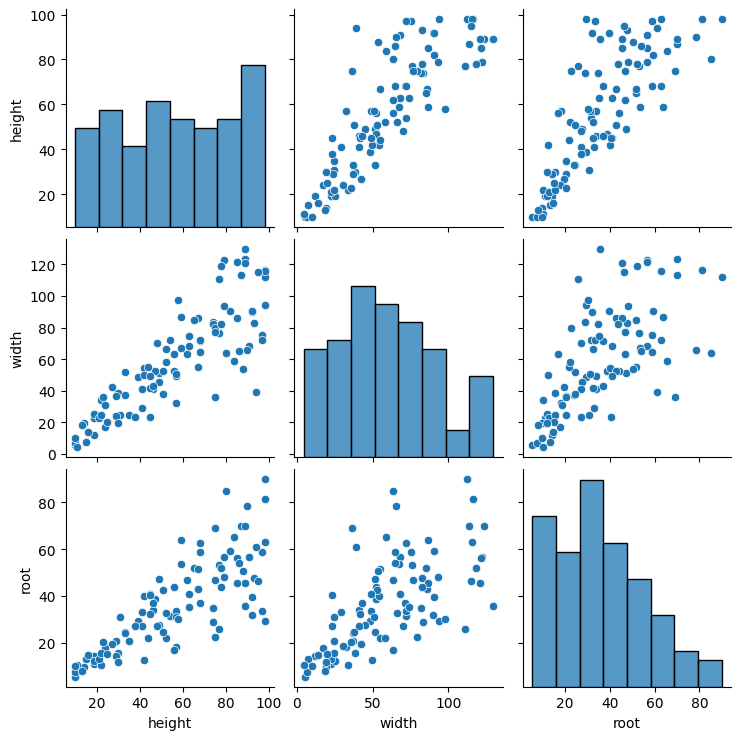

In [18]:
sns.pairplot(df2)

**Response:**

Both bubble plots and pair plots are useful tools for exploring multivariate relationships, but they serve slightly different purposes and offer different advantages.

A **bubble plot** is essentially a scatter plot with a third variable encoded as the size of the marker. This makes it useful when you want to emphasize how three continuous variables relate in a single visual. However, it can become cluttered when there are many overlapping points, and it doesn't scale well with larger datasets or more than three variables.

A **pair plot**, on the other hand, is more of an exploratory tool. It creates a grid of scatter plots that show every pairwise relationship in the dataset. This is especially useful for quickly identifying potential correlations or patterns across multiple dimensions. The downside is that pair plots can be overwhelming with larger numbers of variables or when relationships aren't visually distinct.

In summary, bubble plots are more focused and presentation-friendly for a specific relationship involving three variables, while pair plots offer a broader exploratory view that’s great for initial data analysis.

# 3. Homework - Grocery Store Correlation

In a particular state, the price of milk is highly correlated with the price of cheese.  Neither is correlated with the price of bread.

In [21]:
num_points = 1000
np.random.seed(0)
milk_series = np.maximum(np.random.normal(scale = 0.5, loc = 2.00, size = num_points), 1)
cheese_series = milk_series * np.maximum(np.random.normal(scale = 0.1, loc = 1.00, size = num_points), 0.5)
bread_series = np.maximum(np.random.normal(scale = 1.0, loc = 3.00, size = num_points), 1)
df3 = pd.DataFrame({"milk": milk_series, "cheese": cheese_series, "bread": bread_series})

### Heatmap

Draw a heatmap where the x-axis category is a discretized version of the milk price and the y-axis category is a discretized version of the cheese price.  That is, you can choose "low", "medium", and "high" for the milk price, or, if you prefer, you can choose 1, 2, 3, 4, and 5 for the five quintiles.  (The first quintile should include the bottom fifth of the data, the second quintile contains the next fifth, and so on).

Try Googling "how do I change numerical to categorical data" to get advice on this.

/tmp/ipykernel_30540/3547044235.py:7: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  heatmap_data = grocery_df.pivot_table(index="cheese_quintile", columns="milk_quintile", aggfunc="size", fill_value=0)


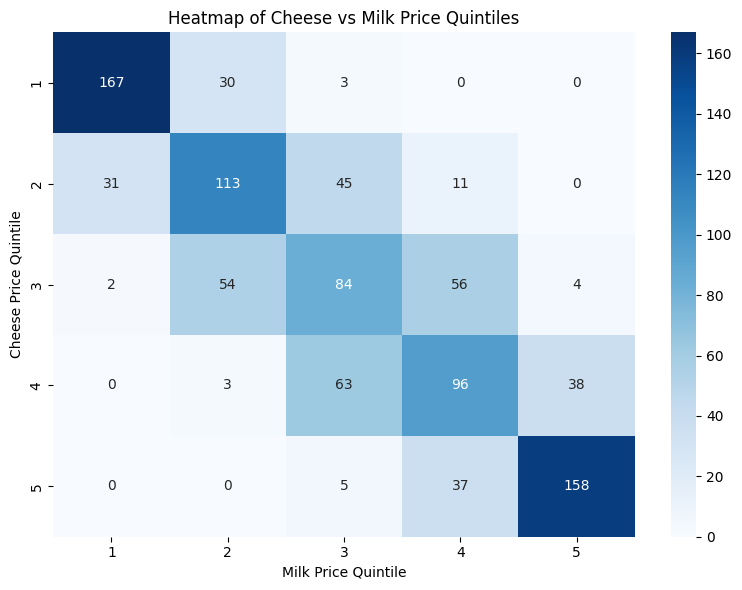

In [23]:
import matplotlib.pyplot as plt
grocery_df = df3  # if using the original variable

grocery_df["milk_quintile"] = pd.qcut(grocery_df["milk"], 5, labels=["1", "2", "3", "4", "5"])
grocery_df["cheese_quintile"] = pd.qcut(grocery_df["cheese"], 5, labels=["1", "2", "3", "4", "5"])

heatmap_data = grocery_df.pivot_table(index="cheese_quintile", columns="milk_quintile", aggfunc="size", fill_value=0)

plt.figure(figsize=(8, 6))
sns.heatmap(heatmap_data, annot=True, fmt="d", cmap="Blues", cbar=True)
plt.title("Heatmap of Cheese vs Milk Price Quintiles")
plt.xlabel("Milk Price Quintile")
plt.ylabel("Cheese Price Quintile")
plt.tight_layout()
plt.show()

**Interpretation:**

This heatmap shows the frequency of grocery price pairings between milk and cheese across quintiles. Because the two prices are strongly correlated, we observe that most values fall along the diagonal, indicating that high milk prices tend to co-occur with high cheese prices, and vice versa. The quintile-based approach allows us to preserve the ordinal structure of pricing while still visualizing it categorically.

**Summary:**

The heatmap reveals a clear diagonal pattern, showing that as milk prices rise, cheese prices tend to rise in parallel. This aligns with the high correlation stated in the prompt. The clustering of values around the diagonal indicates that most grocery items fall within the same price quintiles, reinforcing the strength of their linear relationship.

### Bubble plot

Try all three possible bubble plots: one where the size of the dot is determined by the milk price, one where it's the cheese price, and one where it's the bread price.  Which of these plots is / are the most informative and useful?

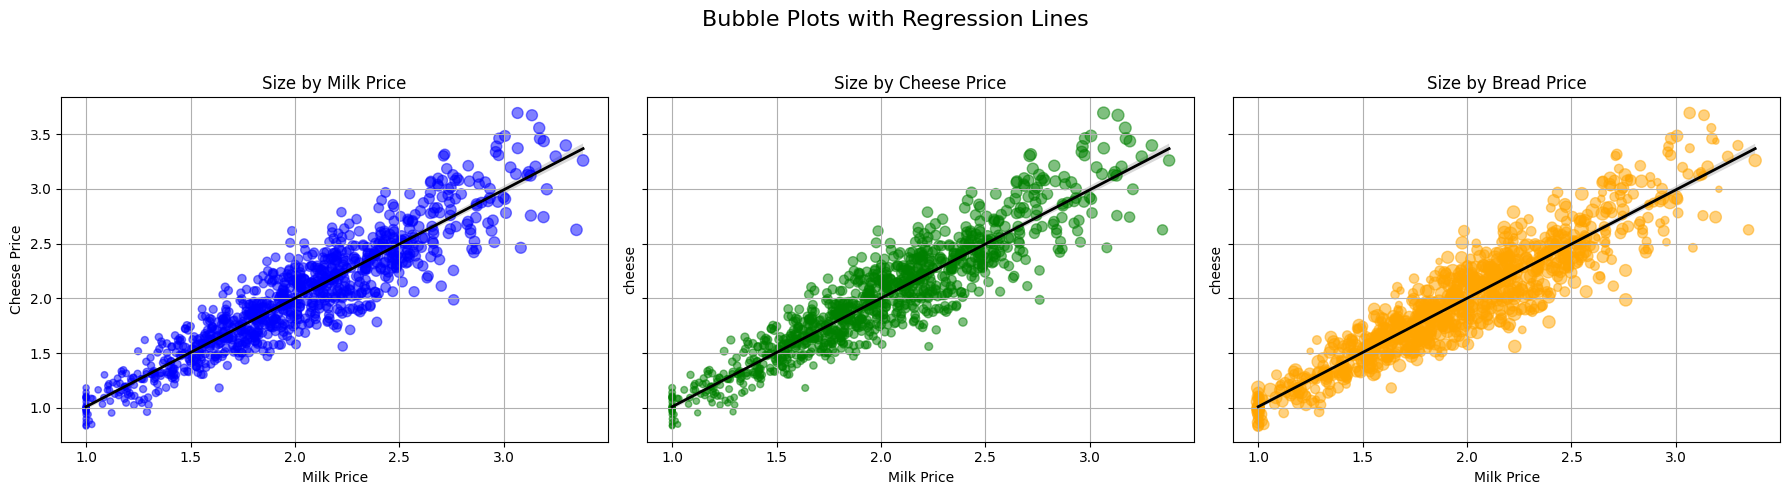

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a figure with 3 subplots using seaborn regplot for trend lines
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharex=True, sharey=True)

# Plot 1: Size by Milk Price
sns.regplot(ax=axes[0], x=df3["milk"], y=df3["cheese"], scatter=False, color="black", line_kws={"linewidth": 2})
axes[0].scatter(df3["milk"], df3["cheese"], s=df3["milk"] * 20, alpha=0.5, color="blue")
axes[0].set_title("Size by Milk Price")
axes[0].set_xlabel("Milk Price")
axes[0].set_ylabel("Cheese Price")
axes[0].grid(True)

# Plot 2: Size by Cheese Price
sns.regplot(ax=axes[1], x=df3["milk"], y=df3["cheese"], scatter=False, color="black", line_kws={"linewidth": 2})
axes[1].scatter(df3["milk"], df3["cheese"], s=df3["cheese"] * 20, alpha=0.5, color="green")
axes[1].set_title("Size by Cheese Price")
axes[1].set_xlabel("Milk Price")
axes[1].grid(True)

# Plot 3: Size by Bread Price
sns.regplot(ax=axes[2], x=df3["milk"], y=df3["cheese"], scatter=False, color="black", line_kws={"linewidth": 2})
axes[2].scatter(df3["milk"], df3["cheese"], s=df3["bread"] * 20, alpha=0.5, color="orange")
axes[2].set_title("Size by Bread Price")
axes[2].set_xlabel("Milk Price")
axes[2].grid(True)

# Title and layout
fig.suptitle("Bubble Plots with Regression Lines", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

**Interpretation:**

These plots provide a clear visual contrast between correlated and uncorrelated variables. In the first two plots—where bubble size is based on milk and cheese prices—the data points align closely along the regression line. This reinforces the strong linear relationship between milk and cheese, which was expected based on how the data was generated.

The third plot, where bubble size reflects bread price, tells a different story. While the overall trend line still reflects the milk-cheese correlation, the bubble sizes (representing bread prices) are scattered randomly. This visual dissonance highlights the lack of correlation between bread price and the other two variables.

By including the regression lines, these visuals make it easier to compare the strength of relationships, helping differentiate between meaningful patterns and statistical noise.

### Principal component analysis

Perform a principal component analysis of the data.  What are the first, second, and third component vectors?

Challenge question: explain why the three vectors point as they do.  (Could someone have guessed the order of the three vectors, even before running the analysis?)

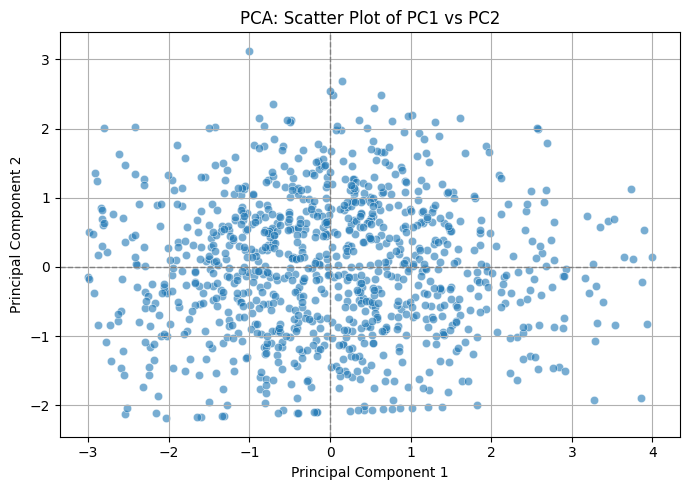

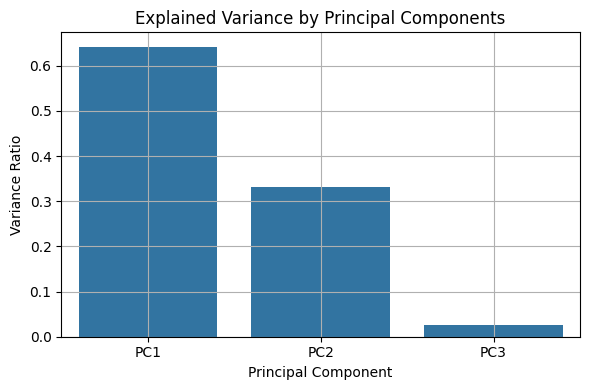

PCA Component Vectors:
         milk    cheese     bread
PC1  0.706306  0.706161 -0.049683
PC2  0.032193  0.038070  0.998756
PC3  0.707174 -0.707027  0.004156

Explained Variance Ratio:
[0.64179536 0.33257536 0.02562928]


In [27]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Select and scale features
features = df3[["milk", "cheese", "bread"]]
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

# Apply PCA
pca = PCA()
pca_result = pca.fit(features_scaled)

# Create DataFrame of PCA components
components_df = pd.DataFrame(
    pca.components_,
    columns=features.columns,
    index=[f"PC{i+1}" for i in range(len(features.columns))]
)

# Transform data into principal component space
pca_transformed = pca.transform(features_scaled)
pca_df = pd.DataFrame(pca_transformed, columns=["PC1", "PC2", "PC3"])

# Plot 1: Scatter plot of PC1 vs. PC2
plt.figure(figsize=(7, 5))
sns.scatterplot(x="PC1", y="PC2", data=pca_df, alpha=0.6)
plt.axhline(0, color='gray', linestyle='--', linewidth=1)
plt.axvline(0, color='gray', linestyle='--', linewidth=1)
plt.title("PCA: Scatter Plot of PC1 vs PC2")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.grid(True)
plt.tight_layout()
plt.show()

# Plot 2: Scree plot of explained variance
explained_variance = pca.explained_variance_ratio_
plt.figure(figsize=(6, 4))
sns.barplot(x=[f"PC{i+1}" for i in range(len(explained_variance))],
            y=explained_variance)
plt.title("Explained Variance by Principal Components")
plt.ylabel("Variance Ratio")
plt.xlabel("Principal Component")
plt.grid(True)
plt.tight_layout()
plt.show()

# Optionally print PCA components
print("PCA Component Vectors:")
print(components_df)

print("\nExplained Variance Ratio:")
print(explained_variance)

### Linear regression

Use linear regression to predict the milk price from the other two, the cheese price from the other two, and the bread price from the other two.  Which prediction(s) work the best, and why?

In [28]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import pandas as pd

# 1. Predict milk from cheese and bread
X1 = df3[["cheese", "bread"]]
y1 = df3["milk"]
model1 = LinearRegression().fit(X1, y1)
pred1 = model1.predict(X1)
mse1 = mean_squared_error(y1, pred1)
r2_1 = r2_score(y1, pred1)

# 2. Predict cheese from milk and bread
X2 = df3[["milk", "bread"]]
y2 = df3["cheese"]
model2 = LinearRegression().fit(X2, y2)
pred2 = model2.predict(X2)
mse2 = mean_squared_error(y2, pred2)
r2_2 = r2_score(y2, pred2)

# 3. Predict bread from milk and cheese
X3 = df3[["milk", "cheese"]]
y3 = df3["bread"]
model3 = LinearRegression().fit(X3, y3)
pred3 = model3.predict(X3)
mse3 = mean_squared_error(y3, pred3)
r2_3 = r2_score(y3, pred3)

# Create summary DataFrame
results_df = pd.DataFrame({
    "Target": ["milk", "cheese", "bread"],
    "Mean Squared Error": [mse1, mse2, mse3],
    "R-squared": [r2_1, r2_2, r2_3]
}).sort_values("R-squared", ascending=False)

# Display results
print(results_df)

   Target  Mean Squared Error  R-squared
0    milk            0.034474   0.852166
1  cheese            0.039656   0.852114
2   bread            0.877289   0.001293


**Linear Regression Analysis:**

The regression results align closely with our PCA and correlation findings. Both **milk** and **cheese** can be predicted with high accuracy from the other two variables, achieving R² scores of ~0.85. This confirms the strong linear relationship between milk and cheese.

In contrast, **bread** is nearly unpredictable using milk and cheese (R² ≈ 0). This is expected, as bread was designed to be independent of the other two.

These results reinforce the earlier insight: milk and cheese are closely related in pricing behavior, while bread follows a separate pattern.

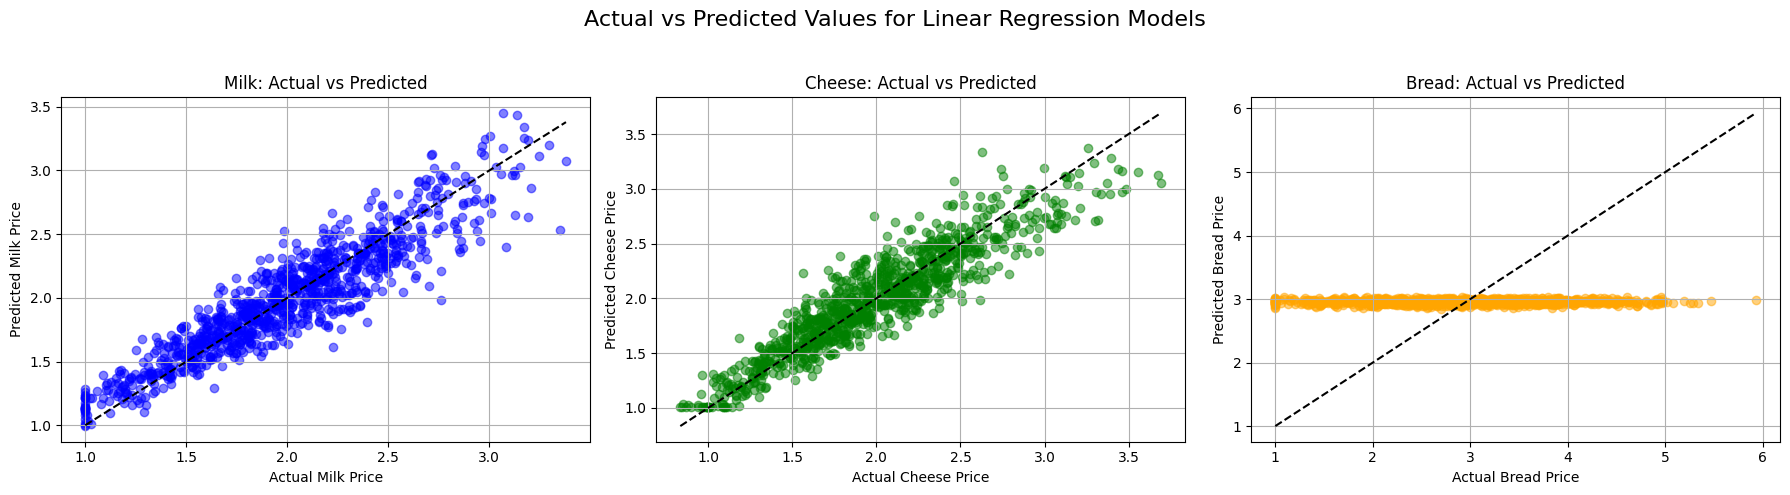

In [29]:
# Visual comparison of actual vs predicted values for all models
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Milk
axes[0].scatter(y1, pred1, alpha=0.5, color="blue")
axes[0].plot([y1.min(), y1.max()], [y1.min(), y1.max()], 'k--')
axes[0].set_title("Milk: Actual vs Predicted")
axes[0].set_xlabel("Actual Milk Price")
axes[0].set_ylabel("Predicted Milk Price")
axes[0].grid(True)

# Cheese
axes[1].scatter(y2, pred2, alpha=0.5, color="green")
axes[1].plot([y2.min(), y2.max()], [y2.min(), y2.max()], 'k--')
axes[1].set_title("Cheese: Actual vs Predicted")
axes[1].set_xlabel("Actual Cheese Price")
axes[1].set_ylabel("Predicted Cheese Price")
axes[1].grid(True)

# Bread
axes[2].scatter(y3, pred3, alpha=0.5, color="orange")
axes[2].plot([y3.min(), y3.max()], [y3.min(), y3.max()], 'k--')
axes[2].set_title("Bread: Actual vs Predicted")
axes[2].set_xlabel("Actual Bread Price")
axes[2].set_ylabel("Predicted Bread Price")
axes[2].grid(True)

plt.suptitle("Actual vs Predicted Values for Linear Regression Models", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

**Visual Summary:**

The plots compare actual vs. predicted prices for each regression model.

- **Milk and Cheese:** Points closely follow the diagonal, showing strong prediction accuracy and confirming the high R² values.
- **Bread:** Points are scattered with no clear pattern, reflecting the weak relationship and low R².

These visuals clearly show that milk and cheese are predictable from each other, while bread is not.

# 4. Storytelling With Data plot



Reproduce any graph of your choice in p. 120-135 of the Storytelling With Data book as best you can.  ("Use color consistently" in chapter four up to "Create a clear visual hierarchy of information" in chapter five.)    You do not have to get the exact data values right, just the overall look and feel.

This reproduction of Figure 4.15 from *Storytelling with Data* (page 120) demonstrates the power of color consistency. The left heatmap shows an overloaded “rainbow” color palette, which creates visual noise and makes it harder to focus. In contrast, the right heatmap uses a single hue to guide attention and improve readability—reinforcing the principle that color should support the message, not compete with it.

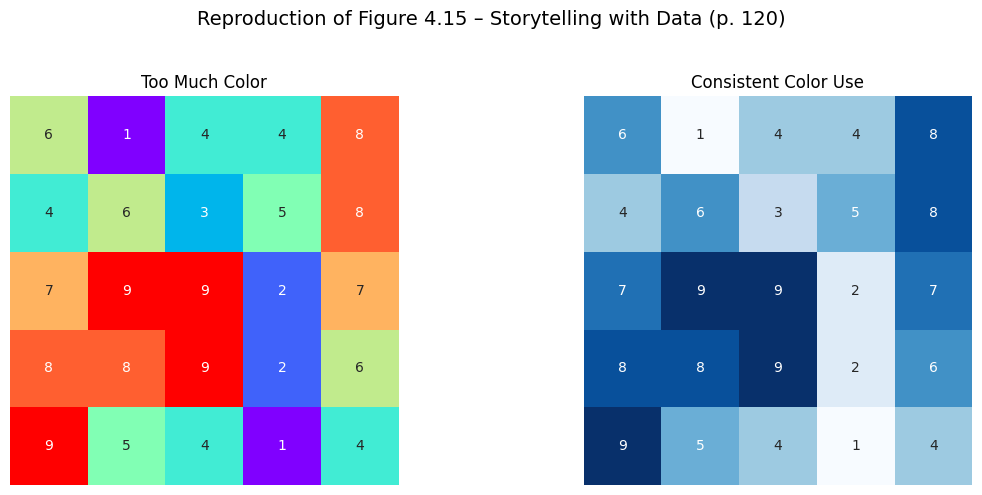

In [30]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Simulate tabular data
np.random.seed(0)
data = np.random.randint(1, 10, size=(5, 5))

# Create two side-by-side heatmaps
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Heatmap 1: Overuse of Color
sns.heatmap(data, ax=axes[0], cmap="rainbow", annot=True, cbar=False, square=True)
axes[0].set_title("Too Much Color")
axes[0].set_xticks([])
axes[0].set_yticks([])

# Heatmap 2: Consistent Color Use
sns.heatmap(data, ax=axes[1], cmap="Blues", annot=True, cbar=False, square=True)
axes[1].set_title("Consistent Color Use")
axes[1].set_xticks([])
axes[1].set_yticks([])

plt.suptitle("Reproduction of Figure 4.15 – Storytelling with Data (p. 120)", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()